# Notebook 03
Notebook com intuito de analisar a evolução estrutural do mercado literário ao longo das décadas e identificar oportunidades por meio do dataset do Booklog.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid", palette="RdPu")
df = pd.read_csv('datasets/books.csv')

df['decada'] = (df['published_year'] // 10) * 10

# A indústria está imprimindo livros menores com o passar dos anos?
A primeira analise se baseira nos hábitos de leitura nesta era moderna, em que  compete com telas e redes sociais, isso de alguma forma impactou o encurtamento dos livros?


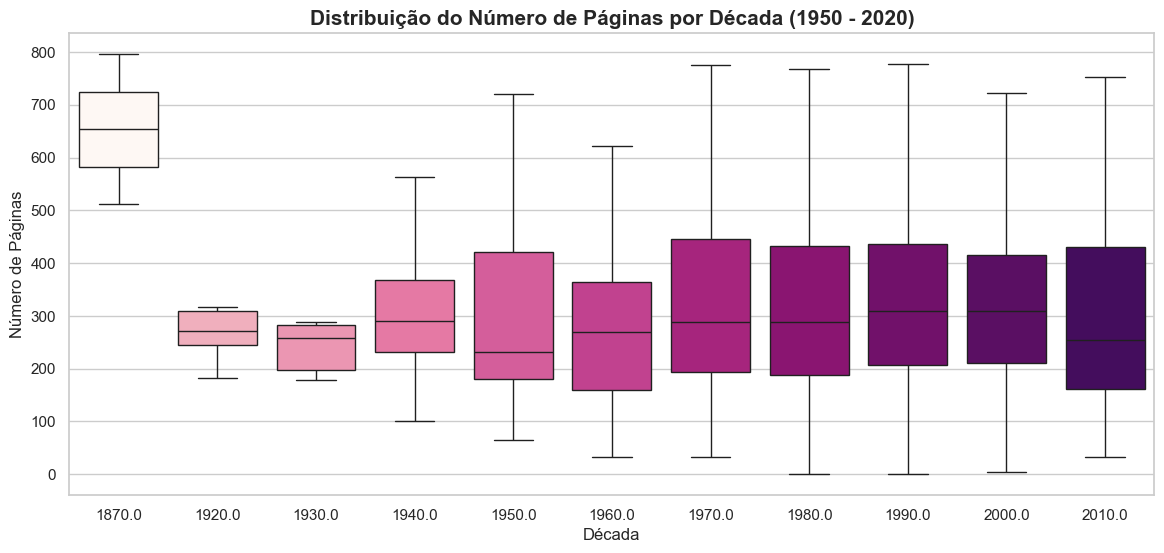

In [3]:
plt.figure(figsize=(14,6))

sns.boxplot(data=df, x='decada', y='num_pages', palette='RdPu', hue='decada', showfliers=False, legend=False)

plt.title('Distribuição do Número de Páginas por Década (1950 - 2020)', fontsize=15, fontweight='bold')
plt.xlabel('Década', fontsize=12)
plt.ylabel('Número de Páginas', fontsize=12)

plt.show()

# Houve algum crescimento ou declínio nos principais gêneros literários nas últimas décadas?
Proximo grafico foca na taxa de crescimento dos gêneros dentro do dataset, algum genêro esta tendo ascensão? ou existe algum que esta perdendo força com o tempo?

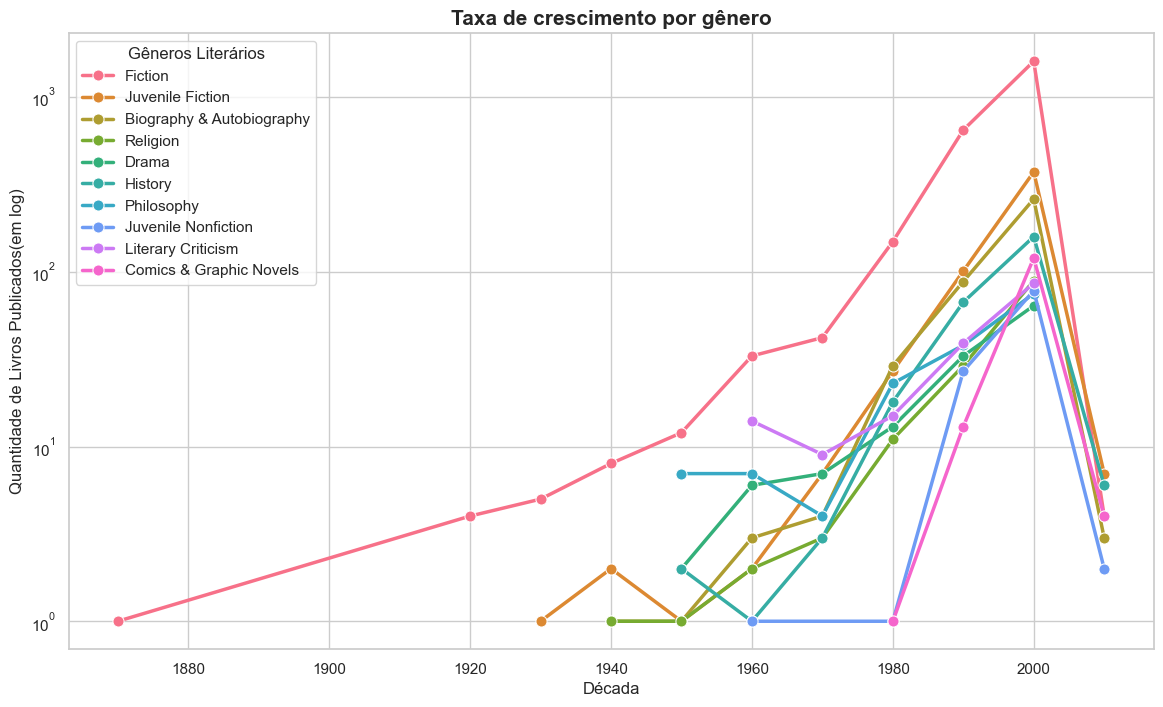

In [4]:
topGeneros = df['categories'].value_counts().head(10).index
df_tendencia = df[df['categories'].isin(topGeneros)]

crescimento = df_tendencia.groupby(['decada', 'categories']).size().reset_index(name='qtd_livros')
plt.figure(figsize=(14, 8))
sns.lineplot(data=crescimento, x='decada', y='qtd_livros', hue='categories', marker='o', linewidth=2.5, markersize=8)


plt.yscale('log')
plt.title('Taxa de crescimento por gênero', fontsize=15, fontweight='bold')
plt.xlabel('Década', fontsize=12)
plt.ylabel('Quantidade de Livros Publicados(em log)', fontsize=12)
plt.legend(title='Gêneros Literários')

plt.show()

# Oferta x demanda dos genêros literarios
Essa analise foca em encontrar algum genêro que não esta sendo explorado mas possui um bom volume de avaliações e aqueles que mesmo saturados de livros, ainda mantem bons volumes de avaliações.

Gênero: Detective and mystery stories, Oferta: 16 livros, Demanda: 6156.0 avaliações
Gênero: Fiction, Oferta: 2510 livros, Demanda: 2709.0 avaliações
Gênero: Juvenile Fiction, Oferta: 521 livros, Demanda: 1364.0 avaliações
Gênero: Humor, Oferta: 32 livros, Demanda: 1314.0 avaliações
Gênero: Fantasy fiction, Oferta: 15 livros, Demanda: 1113.0 avaliações
Gênero: True Crime, Oferta: 12 livros, Demanda: 965.0 avaliações
Gênero: Biography & Autobiography, Oferta: 390 livros, Demanda: 963.5 avaliações
Gênero: English fiction, Oferta: 18 livros, Demanda: 953.5 avaliações
Gênero: Self-Help, Oferta: 36 livros, Demanda: 932.5 avaliações
Gênero: Comics & Graphic Novels, Oferta: 138 livros, Demanda: 891.0 avaliações


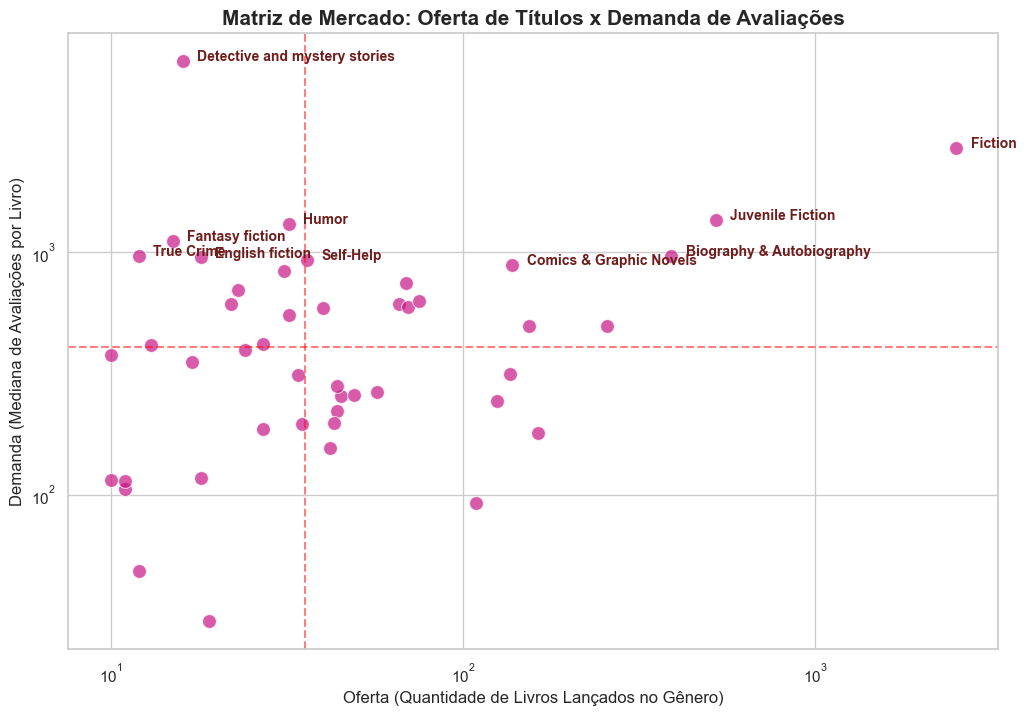

In [5]:
dfMatriz = df.groupby('categories').agg(ofertaLivros=('title', 'count'), demandaAvaliacoes=('ratings_count', 'median')).reset_index()

dfMatriz = dfMatriz[dfMatriz['ofertaLivros'] >= 10]

mediaOferta = dfMatriz['ofertaLivros'].median()
mediaDemanda = dfMatriz['demandaAvaliacoes'].median()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=dfMatriz, x='ofertaLivros', y='demandaAvaliacoes', color='#C71585', s=100, alpha=0.7)

plt.axvline(mediaOferta, color='red', linestyle='--', alpha=0.5)
plt.axhline(mediaDemanda, color='red', linestyle='--', alpha=0.5)

top_maiores_medianas = dfMatriz.nlargest(10, 'demandaAvaliacoes')

for index, row in top_maiores_medianas.iterrows():
    plt.text(row['ofertaLivros'] * 1.1, row['demandaAvaliacoes'], row['categories'], fontsize=10, fontweight='bold', color='#6F1D1B')
    print(f"Gênero: {row['categories']}, Oferta: {row['ofertaLivros']} livros, Demanda: {row['demandaAvaliacoes']} avaliações")

plt.title('Matriz de Mercado: Oferta de Títulos x Demanda de Avaliações', fontsize=15, fontweight='bold')
plt.xlabel('Oferta (Quantidade de Livros Lançados no Gênero)', fontsize=12)
plt.ylabel('Demanda (Mediana de Avaliações por Livro)', fontsize=12)

plt.xscale('log')
plt.yscale('log')

plt.show()

# Conclusão do Notebook 03
Chegamos a conclusão que existe uma tendência no tamanho dos livros menores, a análise de crescimento mostra que o gênero Fiction não apenas domina em volume, mas também apresenta uma taxa de crescimento constante e por ultimo a Matriz de Mercado identificou gêneros como "Detective and mystery stories" apresentam alta demanda e possuem baixa oferta.